In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
legend_properties = {'weight':'bold'}
nus_blue = "#003D7C"
nus_orange = "#EF7C00"
# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"
# Morandi six colors
morandi_blue = "#046586"
morandi_green =  "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"
# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"
# Red and Blue
strong_red = "#A61C5D"
strong_blue = "#1B64A4"

# Shallow-deep pair
shallow_purple = "#EAD7EA"
deep_purple = "#BA9DB9"
shallow_cyan = "#A9D5E0"
deep_cyan = "#48C0BF"
shallow_blue = "#B6DAEC"
deep_blue = "#98CFE4"
shallow_pink = "#F5E0E5"
deep_pink = "#E5A7B6"
shallow_green = "#C2DED0"
deep_green = "#A5C6B1"

color_pairs = [[shallow_purple, deep_purple],  [shallow_green, deep_green],
               [shallow_blue, deep_blue], [shallow_pink, deep_pink], [shallow_cyan, deep_cyan],
               [shallow_grey, deep_grey]]
morandi_colors = [morandi_blue, morandi_green, morandi_yellow, morandi_orange, morandi_pink, morandi_red, morandi_purple]
import os
from pathlib import Path



In [33]:
from pathlib import Path
import pickle
import numpy as np

# =========================
# Configuration
# =========================
result_folder = Path(r"/Volumes/T7/data/gst-0112-26/Maturity")

agent_num = 200
K_list = list(range(9))
maturity_threshold_list = [0.0, 0.1, 0.2, 0.3, 0.4,
                           0.5, 0.6, 0.7, 0.8, 0.9]

condition_labels = {
    "gg": "G → G",
    "gs": "G → S",
    "sg": "S → G",
    "ss": "S → S",
}

dv_labels = {
    "breakthrough_rank": "Best solution rank",
    "breakthrough_fitness": "Best solution fitness",
    "diversity": "Diversity",
}

def load_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)

def result_file(prefix, maturity_threshold, dv):
    return result_folder / f"{prefix}_maturity_threshold_{maturity_threshold}_{dv}_across_K_size_{agent_num}"

# =========================
# Diagnose available files
# =========================
print("Result folder:", result_folder)
print("Folder exists:", result_folder.exists())

available_files = sorted([p.name for p in result_folder.iterdir()]) if result_folder.exists() else []
print("Number of files in folder:", len(available_files))
print("First 10 files:")
for name in available_files[:10]:
    print("  ", name)

# =========================
# Load results
# =========================
def load_maturity_visibility_results(prefixes=("gg", "gs", "sg", "ss"), strict=True):
    data = {}
    missing_files = []

    for prefix in prefixes:
        data[prefix] = {}

        for dv in dv_labels:
            rows = []

            for maturity_threshold in maturity_threshold_list:
                path = result_file(prefix, maturity_threshold, dv)

                if not path.exists():
                    missing_files.append(path)
                    continue

                values = np.asarray(load_pickle(path), dtype=float)
                rows.append(values)

            if rows:
                data[prefix][dv] = np.vstack(rows)

    if missing_files:
        print("\nMissing files:")
        for path in missing_files[:30]:
            print("  -", path.name)

        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        print("\nPossible causes:")
        print("1. result_folder is not the folder where the scripts saved outputs.")
        print("2. Some scripts have not finished.")
        print("3. agent_num is different from the saved file name.")
        print("4. File prefix is different, e.g., sg/gs/ss/gg.")

        if strict:
            raise FileNotFoundError("Some expected result files are missing.")

    return data

data = load_maturity_visibility_results(strict=True)

# Quick shape check
print("\nLoaded data shapes:")
for prefix in data:
    for dv in data[prefix]:
        print(prefix, dv, data[prefix][dv].shape)

Result folder: /Volumes/T7/data/gst-0112-26/Maturity
Folder exists: True
Number of files in folder: 155
First 10 files:
   ._Rank_across_maturity.png
   ._Rank_across_maturity_average_K4_K8.png
   ._figure_1_best_rank_across_maturity_visibility.png
   ._figure_2_best_fitness_across_maturity_visibility.png
   ._figure_3_diversity_across_maturity_visibility.png
   ._figure_4_gg_best_rank_by_K_across_maturity_visibility.png
   ._figure_4_gs_best_rank_by_K_across_maturity_visibility.png
   ._figure_4_sg_best_rank_by_K_across_maturity_visibility.png
   ._figure_4_ss_best_rank_by_K_across_maturity_visibility.png
   Crowd.py

Loaded data shapes:
gg breakthrough_rank (10, 9)
gg breakthrough_fitness (10, 9)
gg diversity (10, 9)
gs breakthrough_rank (10, 9)
gs breakthrough_fitness (10, 9)
gs diversity (10, 9)
sg breakthrough_rank (10, 9)
sg breakthrough_fitness (10, 9)
sg diversity (10, 9)
ss breakthrough_rank (10, 9)
ss breakthrough_fitness (10, 9)
ss diversity (10, 9)


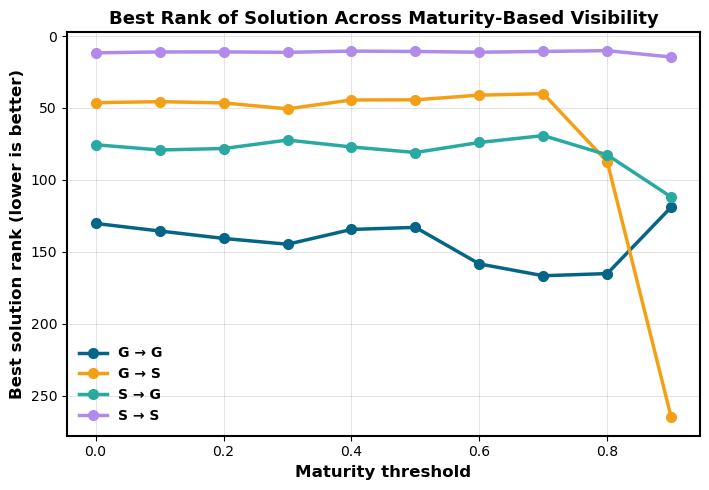

Saved: /Volumes/T7/data/gst-0112-26/Maturity/figure_1_best_rank_across_maturity_visibility.png


In [34]:
# =========================
# Figure 1: Main figure — best solution rank across maturity-based visibility
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

condition_colors = {
    "gg": morandi_blue,
    "gs": morandi_orange,
    "sg": morandi_green,
    "ss": morandi_purple,
}

x = maturity_threshold_list
for prefix in ["gg", "gs", "sg", "ss"]:
    # Average across K to show the main maturity pattern.
    y = data[prefix]["breakthrough_rank"].mean(axis=1)
    ax.plot(x, y, marker="o", linewidth=2.5, markersize=7,
            label=condition_labels[prefix], color=condition_colors[prefix])

ax.invert_yaxis()  # smaller rank means better solution; invert so better is visually higher
ax.set_xlabel("Maturity threshold", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
ax.set_title("Best Rank of Solution Across Maturity-Based Visibility", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)
ax.grid(alpha=0.5)
plt.tight_layout()

output_path = result_folder / "figure_1_best_rank_across_maturity_visibility.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


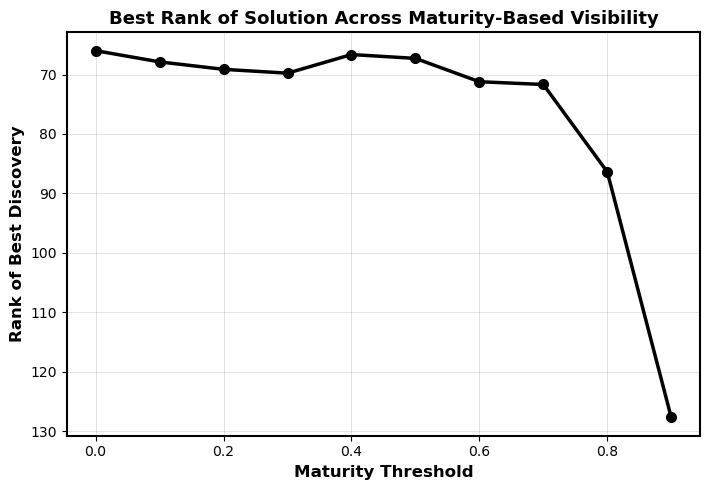

Saved: /Volumes/T7/data/gst-0112-26/Maturity/Rank_across_maturity.png


In [35]:
# =========================
# Figure 2: Best solution rank across maturity-based visibility, averaged across G-S conditions
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

x = maturity_threshold_list

# Average across both K and the four G-S visibility conditions.
y = np.mean([data[prefix]["breakthrough_rank"].mean(axis=1) for prefix in ["gg", "gs", "sg", "ss"]], axis=0)

ax.plot(x, y, marker="o", linewidth=2.5, markersize=7, color="k")

ax.invert_yaxis()
ax.set_xlabel("Maturity Threshold", fontweight="bold", fontsize=12)
ax.set_ylabel("Rank of Best Discovery", fontweight="bold", fontsize=12)
ax.set_title("Best Rank of Solution Across Maturity-Based Visibility", fontweight="bold", fontsize=13)
ax.grid(alpha=0.5)
plt.tight_layout()

output_path = result_folder / "Rank_across_maturity.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)

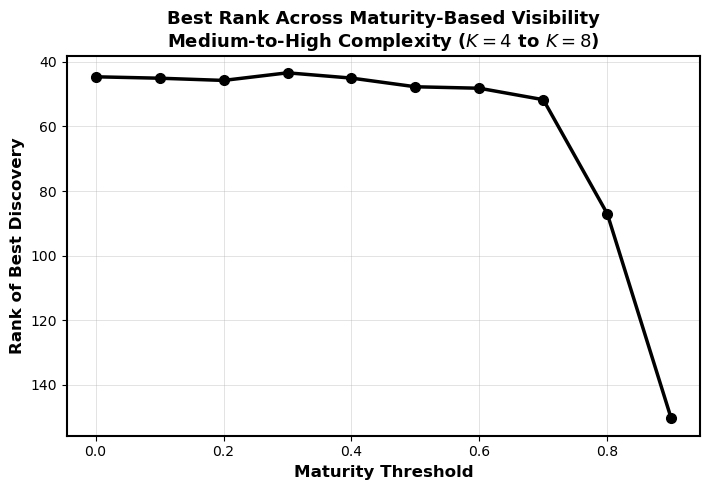

Saved: /Volumes/T7/data/gst-0112-26/Maturity/Rank_across_maturity_average_K4_K8.png


In [36]:
# =========================
# Figure 2 Extension: Best solution rank across maturity-based visibility,
# averaged across G-S conditions and medium-to-high complexity (K=4 to K=8)
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

x = maturity_threshold_list

# Select medium-to-high complexity: K = 4, 5, 6, 7, 8.
medium_high_K_indices = [K_list.index(k) for k in [4, 5, 6, 7, 8]]

# Average across selected K values and the four G-S visibility conditions.
y = np.mean(
    [
        data[prefix]["breakthrough_rank"][:, medium_high_K_indices].mean(axis=1)
        for prefix in ["gg", "gs", "sg", "ss"]
    ],
    axis=0
)

ax.plot(x, y, marker="o", linewidth=2.5, markersize=7, color="k")

ax.invert_yaxis()
ax.set_xlabel("Maturity Threshold", fontweight="bold", fontsize=12)
ax.set_ylabel("Rank of Best Discovery", fontweight="bold", fontsize=12)
ax.set_title("Best Rank Across Maturity-Based Visibility\nMedium-to-High Complexity ($K=4$ to $K=8$)", fontweight="bold", fontsize=13)
ax.grid(alpha=0.5)
plt.tight_layout()

output_path = result_folder / "Rank_across_maturity_average_K4_K8.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)

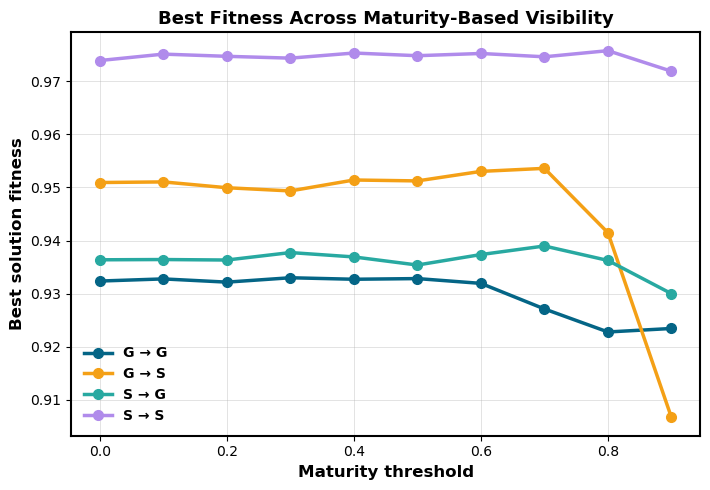

Saved: /Volumes/T7/data/gst-0112-26/Maturity/figure_2_best_fitness_across_maturity_visibility.png


In [37]:
# =========================
# Figure 2: Best solution fitness across maturity-based visibility
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

x = maturity_threshold_list
for prefix in ["gg", "gs", "sg", "ss"]:
    y = data[prefix]["breakthrough_fitness"].mean(axis=1)
    ax.plot(x, y, marker="o", linewidth=2.5, markersize=7,
            label=condition_labels[prefix], color=condition_colors[prefix])

ax.set_xlabel("Maturity threshold", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution fitness", fontweight="bold", fontsize=12)
ax.set_title("Best Fitness Across Maturity-Based Visibility", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)
ax.grid(alpha=0.5)
plt.tight_layout()

output_path = result_folder / "figure_2_best_fitness_across_maturity_visibility.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


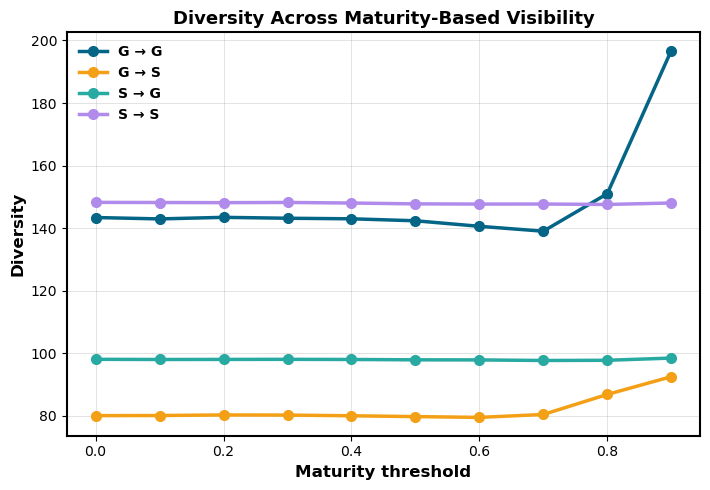

Saved: /Volumes/T7/data/gst-0112-26/Maturity/figure_3_diversity_across_maturity_visibility.png


In [38]:
# =========================
# Figure 3: Diversity across maturity-based visibility
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

x = maturity_threshold_list
for prefix in ["gg", "gs", "sg", "ss"]:
    y = data[prefix]["diversity"].mean(axis=1)
    ax.plot(x, y, marker="o", linewidth=2.5, markersize=7,
            label=condition_labels[prefix], color=condition_colors[prefix])

ax.set_xlabel("Maturity threshold", fontweight="bold", fontsize=12)
ax.set_ylabel("Diversity", fontweight="bold", fontsize=12)
ax.set_title("Diversity Across Maturity-Based Visibility", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)
ax.grid(alpha=0.5)
plt.tight_layout()

output_path = result_folder / "figure_3_diversity_across_maturity_visibility.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


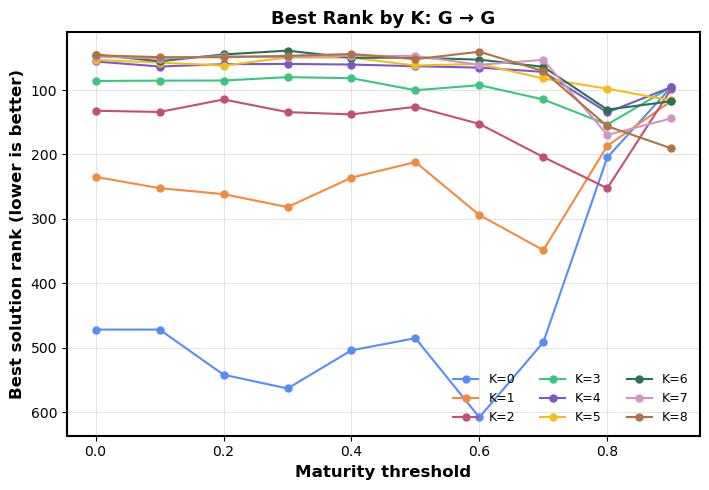

Saved: /Volumes/T7/data/gst-0112-26/Maturity/figure_4_gg_best_rank_by_K_across_maturity_visibility.png


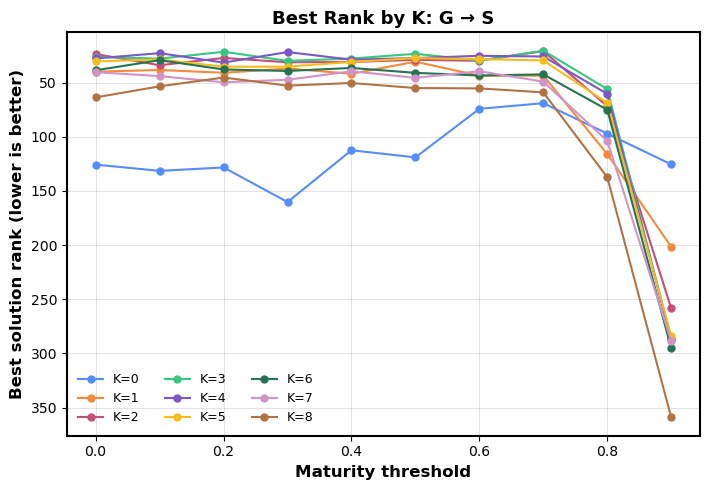

Saved: /Volumes/T7/data/gst-0112-26/Maturity/figure_4_gs_best_rank_by_K_across_maturity_visibility.png


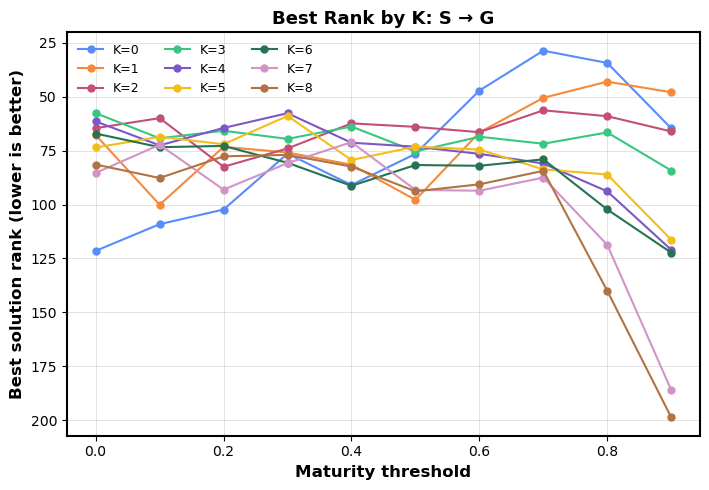

Saved: /Volumes/T7/data/gst-0112-26/Maturity/figure_4_sg_best_rank_by_K_across_maturity_visibility.png


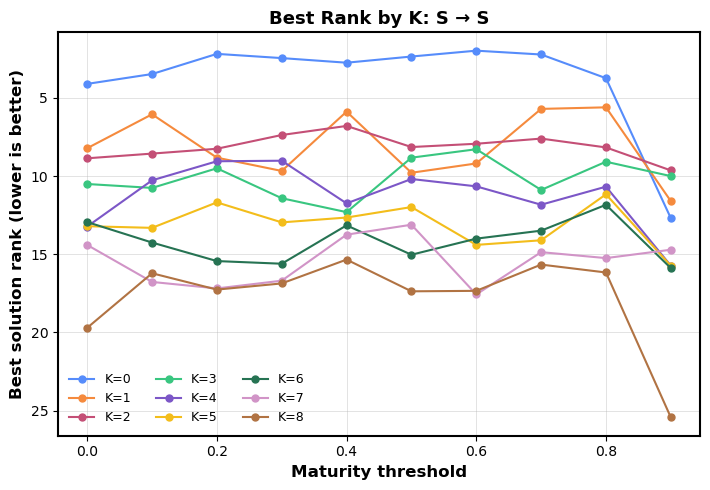

Saved: /Volumes/T7/data/gst-0112-26/Maturity/figure_4_ss_best_rank_by_K_across_maturity_visibility.png


In [39]:
# =========================
# Figure 4: Detailed rank patterns by K
# =========================
# This figure helps diagnose whether the main maturity pattern is driven by low-K or high-K landscapes.
for prefix in ["gg", "gs", "sg", "ss"]:
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    for k_index, K in enumerate(K_list):
        y = data[prefix]["breakthrough_rank"][:, k_index]
        ax.plot(maturity_threshold_list, y, marker="o", linewidth=1.5, markersize=5, label=f"K={K}")

    ax.invert_yaxis()
    ax.set_xlabel("Maturity threshold", fontweight="bold", fontsize=12)
    ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
    ax.set_title(f"Best Rank by K: {condition_labels[prefix]}", fontweight="bold", fontsize=13)
    ax.legend(frameon=False, ncol=3, fontsize=9)
    ax.grid(alpha=0.5)
    plt.tight_layout()

    output_path = result_folder / f"figure_4_{prefix}_best_rank_by_K_across_maturity_visibility.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


In [40]:
# =========================
# Optional helper: inspect exact values as tables
# =========================
def maturity_table(dv="breakthrough_rank", aggregate="mean"):
    """Return a condition-by-maturity table for a selected DV.

    aggregate="mean" averages across K.
    aggregate=None returns the full arrays in data[prefix][dv].
    """
    if aggregate is None:
        return {prefix: data[prefix][dv] for prefix in condition_labels}
    if aggregate != "mean":
        raise ValueError("Only aggregate='mean' or aggregate=None are supported.")
    table = []
    for prefix in ["gg", "gs", "sg", "ss"]:
        row = [condition_labels[prefix]] + data[prefix][dv].mean(axis=1).round(4).tolist()
        table.append(row)
    columns = ["Condition"] + [f"M_v={v}" for v in maturity_threshold_list]
    return table, columns

table, columns = maturity_table("breakthrough_rank")
print(columns)
for row in table:
    print(row)


['Condition', 'M_v=0.0', 'M_v=0.1', 'M_v=0.2', 'M_v=0.3', 'M_v=0.4', 'M_v=0.5', 'M_v=0.6', 'M_v=0.7', 'M_v=0.8', 'M_v=0.9']
['G → G', 130.3233, 135.5617, 140.7372, 144.7806, 134.4917, 133.0406, 158.4667, 166.69, 165.1706, 118.9694]
['G → S', 46.3417, 45.6417, 46.5089, 50.6417, 44.4528, 44.3672, 41.1078, 40.0906, 87.465, 265.1717]
['S → G', 75.6072, 79.2317, 78.2278, 72.33, 77.1417, 80.9906, 74.0172, 69.2261, 82.6794, 111.9222]
['S → S', 11.6844, 11.0717, 11.04, 11.3378, 10.4828, 10.7522, 11.26, 10.7061, 10.185, 14.6022]
